## AVAGAMYA ML Risk Classifier: Full EDA & Training Pipeline
> **Project:** AVAGAMYA” Legal Document Compliance Analyzer  
> **Stack:** FastAPI + Supabase + spaCy + Gemini/Sarvam + **Scikit-learn**  
> **JD Coverage:** Jupyter| Pandas  | NumPy âœ… | Scikit-learn âœ… | Data Cleaning âœ… | Model Evaluation âœ…

---
## ðŸ“Œ Notebook Workflow
1. **Data Ingestion** â€” Pull compliance audit logs from Supabase  
2. **EDA** â€” Distributions, null checks, correlation heatmap  
3. **Feature Engineering** â€” Build 11-dim feature vector from clause text  
4. **Baseline Model** â€” Logistic Regression  
5. **Primary Model** â€” Random Forest with cross-validation  
6. **Evaluation** â€” Classification report, confusion matrix  
7. **Export** â€” Save `.pkl` for FastAPI production use

In [1]:
# â”€â”€ Cell 1: Dependencies 
import sys
import os
import re
import json
import warnings
warnings.filterwarnings('ignore')

# Add project root to path so we can import risk_classifier
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from sklearn.metrics import ConfusionMatrixDisplay

# AVAGAMYA ML module
from ml_models.risk_classifier import (
    generate_synthetic_dataset,
    build_feature_matrix,
    FEATURE_NAMES,
    silver_label,
    train_and_evaluate,
    save_models,
    load_models,
    predict_risk,
    extract_features,
)

# Plot style
sns.set_theme(style='darkgrid', palette='muted', font_scale=1.1)
plt.rcParams['figure.dpi'] = 100
print('âœ… All imports OK')

âœ… All imports OK


In [2]:
# â”€â”€ Cell 2: Data Ingestion (Supabase â†’ Pandas DataFrame) 
from dotenv import load_dotenv
from supabase import create_client

load_dotenv('../.env')

SUPABASE_URL = os.getenv('VITE_SUPABASE_URL', '')
SUPABASE_KEY = os.getenv('VITE_SUPABASE_KEY', '')

df_logs = pd.DataFrame()   # fallback

if SUPABASE_URL and SUPABASE_KEY:
    try:
        client = create_client(SUPABASE_URL, SUPABASE_KEY)
        rows = client.table('compliance_logs').select('*').execute().data
        df_logs = pd.DataFrame(rows)
        print(f'âœ… Loaded {len(df_logs)} rows from Supabase compliance_logs')
    except Exception as e:
        print(f'âš ï¸  Supabase read failed: {e}. Using synthetic data.')
else:
    print('âš ï¸  Supabase not configured. Using synthetic data.')

# generate_synthetic_dataset returns (clauses, labels) tuple - 3 classes balanced
synth_clauses, synth_labels = generate_synthetic_dataset(n=600)

# Build primary DataFrame from synthetic data
df = pd.DataFrame({'clause': synth_clauses, 'risk_label': synth_labels})

# If Supabase data exists, try to enrich with real logs
if not df_logs.empty and 'details' in df_logs.columns:
    real_clauses = df_logs['details'].dropna().astype(str).tolist()
    real_labels  = [silver_label(c) for c in real_clauses]
    df_real = pd.DataFrame({'clause': real_clauses, 'risk_label': real_labels})
    df = pd.concat([df, df_real], ignore_index=True)
    print(f'ðŸ“¦ Combined dataset: {len(df)} rows (synthetic + real)')

print(df.head())
print(f'\nShape: {df.shape}')

âœ… Loaded 164 rows from Supabase compliance_logs
ðŸ“¦ Combined dataset: 764 rows (synthetic + real)
                                              clause risk_label
0  The annual fee of ₹5000 will be levied on the ...     MEDIUM
1  The bank reserves the sole discretion to levy ...       HIGH
2  दंड: ग्राहक को ₹500 का जुर्माना देना होगा यदि ...       HIGH
3  बँक एकट्याच्या विवेकानुसार कोणत्याही क्षणी खात...       HIGH
4  Cardholder shall indemnify and hold harmless t...       HIGH

Shape: (764, 2)


In [3]:
# â”€â”€ Cell 3: Data Cleaning & Basic Stats 
print('=== Data Info ===')
print(df.info())

print('\n=== Null Check ===')
print(df.isnull().sum())

# Drop empty clauses
df = df[df['clause'].str.strip().str.len() > 10].reset_index(drop=True)
df = df.drop_duplicates(subset='clause').reset_index(drop=True)

print(f'\nâœ… After cleaning: {len(df)} rows')
print('\n=== Label Distribution ===')
print(df['risk_label'].value_counts())

=== Data Info ===
<class 'pandas.DataFrame'>
RangeIndex: 764 entries, 0 to 763
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype
---  ------      --------------  -----
 0   clause      764 non-null    str  
 1   risk_label  764 non-null    str  
dtypes: str(2)
memory usage: 12.1 KB
None

=== Null Check ===
clause        0
risk_label    0
dtype: int64

âœ… After cleaning: 74 rows

=== Label Distribution ===
risk_label
MEDIUM    35
HIGH      20
LOW       19
Name: count, dtype: int64


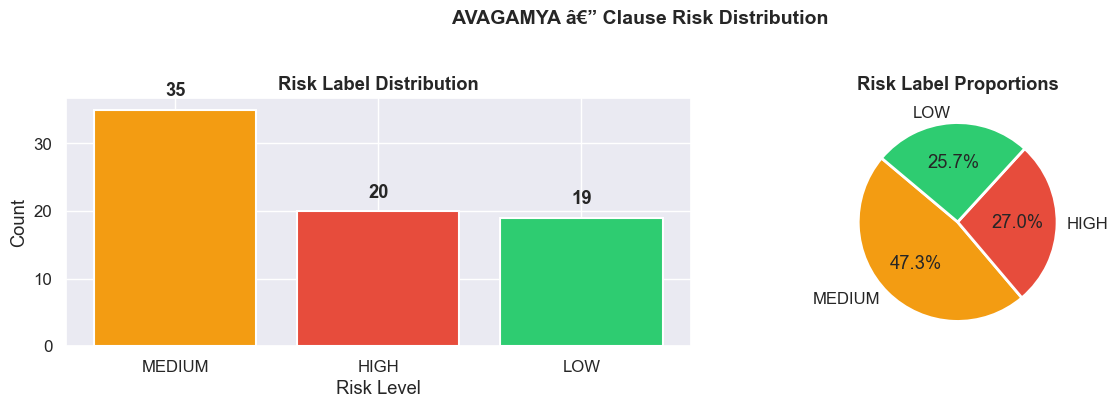

ðŸ’¾ Figure saved: fig_label_distribution.png


In [4]:
# â”€â”€ Cell 4: EDA â€” Label Distribution Bar Chart 
fig, axes = plt.subplots(1, 2, figsize=(13, 4))

# Bar chart
colors = {'HIGH': '#e74c3c', 'MEDIUM': '#f39c12', 'LOW': '#2ecc71'}
vc = df['risk_label'].value_counts()
axes[0].bar(vc.index, vc.values,
            color=[colors.get(l, '#95a5a6') for l in vc.index],
            edgecolor='white', linewidth=1.5)
axes[0].set_title('Risk Label Distribution', fontweight='bold')
axes[0].set_xlabel('Risk Level')
axes[0].set_ylabel('Count')
for i, (label, val) in enumerate(zip(vc.index, vc.values)):
    axes[0].text(i, val + 2, str(val), ha='center', fontweight='bold')

# Pie chart
axes[1].pie(vc.values, labels=vc.index, autopct='%1.1f%%',
            colors=[colors.get(l, '#95a5a6') for l in vc.index],
            startangle=140, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('Risk Label Proportions', fontweight='bold')

plt.suptitle('AVAGAMYA â€” Clause Risk Distribution', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('../notebooks/fig_label_distribution.png', bbox_inches='tight', dpi=120)
plt.show()
print('ðŸ’¾ Figure saved: fig_label_distribution.png')

In [5]:
# â”€â”€ Cell 5: Feature Engineering 
print('âš™ï¸  Extracting 11 features per clause ...')

X_raw = build_feature_matrix(df['clause'].tolist())
df_feats = pd.DataFrame(X_raw, columns=FEATURE_NAMES)
df_feats['risk_label'] = df['risk_label'].values

print('âœ… Feature matrix shape:', X_raw.shape)
print('\n=== Feature Statistics (describe) ===')
print(df_feats[FEATURE_NAMES].describe().round(3))

âš™ï¸  Extracting 11 features per clause ...
âœ… Feature matrix shape: (74, 11)

=== Feature Statistics (describe) ===
       jargon_count  word_count  avg_word_length  flesch_score  has_currency  \
count        74.000      74.000           74.000        74.000        74.000   
mean          0.770      16.716            4.787        53.019         0.473   
std           1.439       4.196            0.675        11.128         0.503   
min           0.000       4.000            3.824        14.665         0.000   
25%           0.000      15.250            4.272        50.000         0.000   
50%           0.000      17.000            4.545        50.610         0.000   
75%           0.000      20.000            5.328        57.605         1.000   
max           4.000      22.000            7.000        76.555         1.000   

       has_percentage  has_devanagari  has_regional_risk  sentence_length_z  \
count          74.000          74.000             74.000             74.000   
m

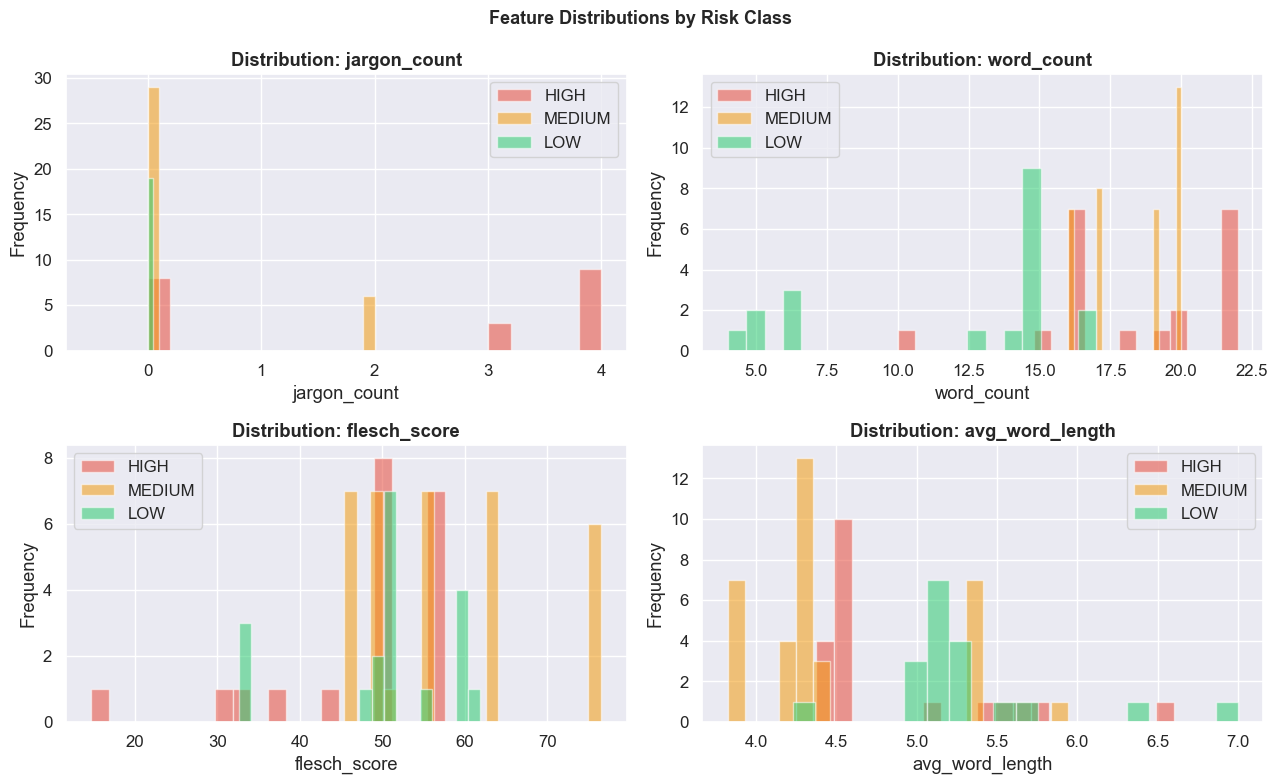

In [6]:
# â”€â”€ Cell 6: EDA â€” Feature Distributions by Risk Class 
plot_feats = ['jargon_count', 'word_count', 'flesch_score', 'avg_word_length']
fig, axes = plt.subplots(2, 2, figsize=(13, 8))

for ax, feat in zip(axes.flatten(), plot_feats):
    for label, color in colors.items():
        subset = df_feats[df_feats['risk_label'] == label][feat]
        ax.hist(subset, bins=20, alpha=0.55, color=color, label=label, edgecolor='white')
    ax.set_title(f'Distribution: {feat}', fontweight='bold')
    ax.set_xlabel(feat)
    ax.set_ylabel('Frequency')
    ax.legend()

plt.suptitle('Feature Distributions by Risk Class', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/fig_feature_distributions.png', bbox_inches='tight', dpi=120)
plt.show()

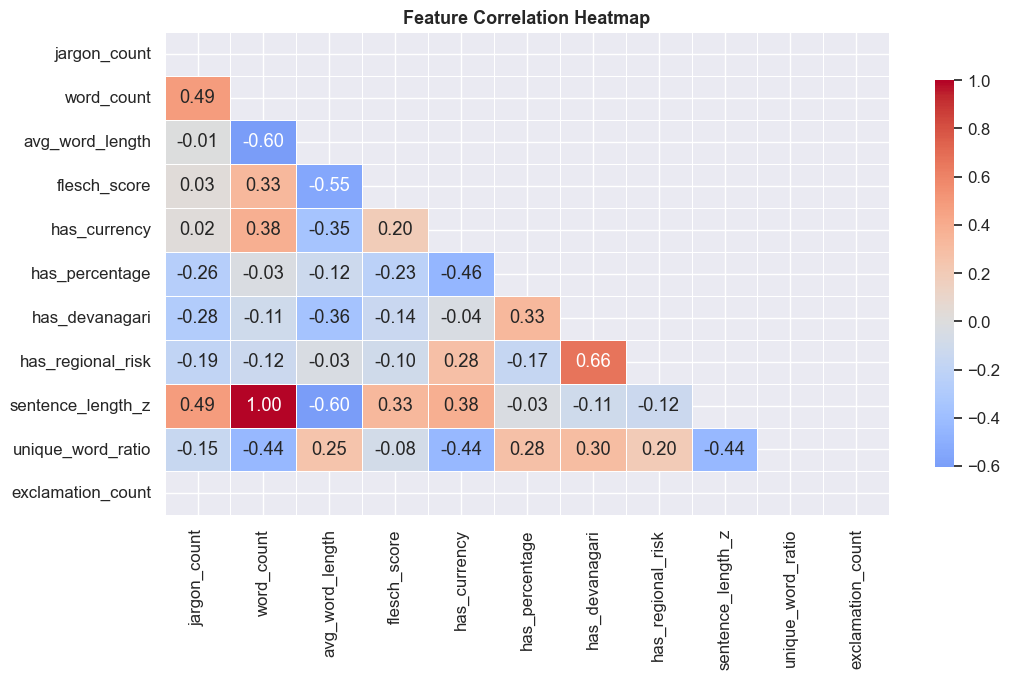

In [7]:
# â”€â”€ Cell 7: Correlation Heatmap 
fig, ax = plt.subplots(figsize=(11, 7))
corr = df_feats[FEATURE_NAMES].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='coolwarm',
            center=0, linewidths=0.5, ax=ax, cbar_kws={'shrink': 0.8})
ax.set_title('Feature Correlation Heatmap', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/fig_correlation_heatmap.png', bbox_inches='tight', dpi=120)
plt.show()

In [8]:
# â”€â”€ Cell 8: Train Models 
result = train_and_evaluate(
    clauses=df['clause'].tolist(),
    labels=df['risk_label'].tolist(),
    test_size=0.20,
    random_state=42,
)


📊 Dataset: 74 clauses
   Label distribution: {'MEDIUM': 35, 'HIGH': 20, 'LOW': 19}

✅ Random Forest Accuracy: 0.9333
   Cross-Val (5-fold):     0.9467 ± 0.0653

📋 Classification Report:
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         4
         LOW       1.00      0.75      0.86         4
      MEDIUM       0.88      1.00      0.93         7

    accuracy                           0.93        15
   macro avg       0.96      0.92      0.93        15
weighted avg       0.94      0.93      0.93        15

🔲 Confusion Matrix:
        HIGH  LOW  MEDIUM
HIGH       4    0       0
LOW        0    3       1
MEDIUM     0    0       7

📌 Baseline Logistic Regression Accuracy: 0.9333
   (RF lift over LR: +0.00pp)

🔍 Feature Importances (RF):
   avg_word_length           █████████ 0.2266
   sentence_length_z         ████████ 0.2035
   word_count                ███████ 0.1951
   jargon_count              ███ 0.0989
   has_percentage        

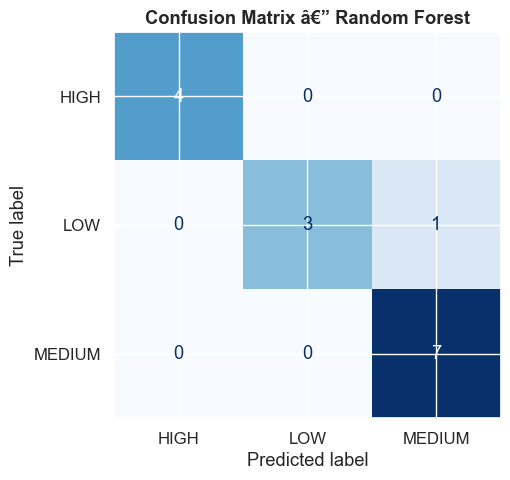

In [9]:
# â”€â”€ Cell 9: Confusion Matrix Plot
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

le  = result['label_encoder']
rf  = result['rf_model']
X   = build_feature_matrix(df['clause'].tolist())
y   = le.transform(df['risk_label'].tolist())
_, X_test, _, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

fig, ax = plt.subplots(figsize=(6, 5))
ConfusionMatrixDisplay.from_estimator(
    rf, X_test, y_test,
    display_labels=le.classes_,
    cmap='Blues', colorbar=False, ax=ax
)
ax.set_title('Confusion Matrix â€” Random Forest', fontweight='bold')
plt.tight_layout()
plt.savefig('../notebooks/fig_confusion_matrix.png', bbox_inches='tight', dpi=120)
plt.show()

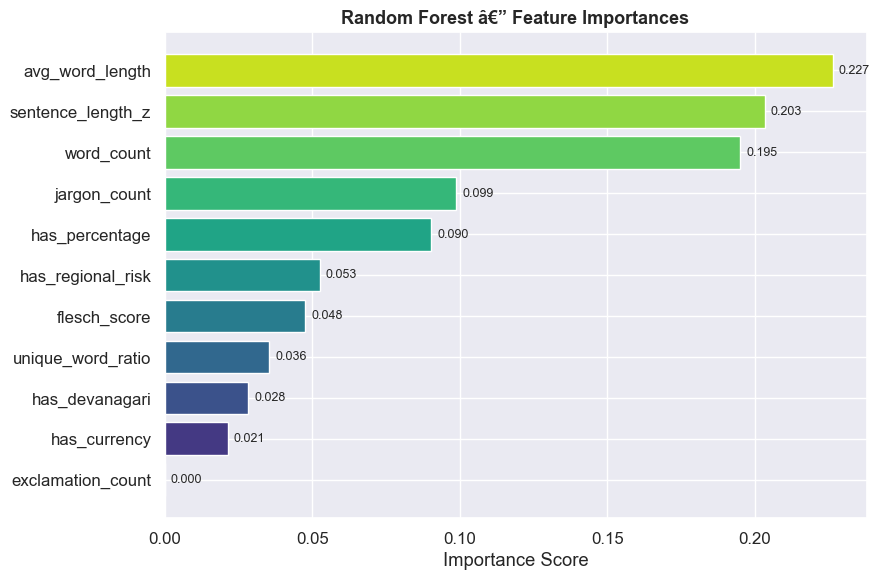

In [10]:
# â”€â”€ Cell 10: Feature Importance Plot 
importances = result['metrics']['feature_importances']
imp_df = pd.DataFrame(importances.items(), columns=['Feature', 'Importance'])
imp_df = imp_df.sort_values('Importance', ascending=True)

fig, ax = plt.subplots(figsize=(9, 6))
bars = ax.barh(imp_df['Feature'], imp_df['Importance'],
               color=sns.color_palette('viridis', len(imp_df)), edgecolor='white')
ax.set_title('Random Forest â€” Feature Importances', fontweight='bold', fontsize=13)
ax.set_xlabel('Importance Score')
for bar, val in zip(bars, imp_df['Importance']):
    ax.text(val + 0.002, bar.get_y() + bar.get_height()/2,
            f'{val:.3f}', va='center', fontsize=9)
plt.tight_layout()
plt.savefig('../notebooks/fig_feature_importance.png', bbox_inches='tight', dpi=120)
plt.show()

In [11]:
# â”€â”€ Cell 11: Save Models to ml_models/ 
save_models(
    result['rf_model'],
    result['lr_model'],
    result['label_encoder'],
    result['metrics'],
)
print('\nâœ… Models ready for FastAPI consumption via POST /analyze/ml-risk')


💾 Models saved → D:\AVAGAMYA\ml_models

âœ… Models ready for FastAPI consumption via POST /analyze/ml-risk


In [12]:
# â”€â”€ Cell 12: Live Inference Demo 
rf_loaded, le_loaded = load_models()

demo_clauses = [
    'The bank reserves the sole discretion to levy a penalty of â‚¹5000 for any breach without notice.',
    'Please retain a copy of this document for your personal records.',
    'Interest at 18% per annum will be charged on outstanding balance after due date.',
    'Cardholder shall indemnify the bank from any unlimited liability arising from default.',
    'You may visit any branch to update your KYC details during working hours.',
]

print('\nðŸ” Live Risk Predictions:')
print('-' * 75)
rows = []
for clause in demo_clauses:
    pred = predict_risk(clause, rf_loaded, le_loaded)
    rows.append({
        'Clause (truncated)': clause[:55] + '...',
        'Predicted Risk':     pred['risk_level'],
        'Confidence':         f"{pred['confidence']*100:.1f}%",
        'HIGH prob':          f"{pred['probabilities'].get('HIGH',0)*100:.1f}%",
    })

pd.set_option('display.max_colwidth', 60)
display(pd.DataFrame(rows))


ðŸ” Live Risk Predictions:
---------------------------------------------------------------------------


,Clause (truncated),Predicted Risk,Confidence,HIGH prob
0,The bank reserves the sole discretion to levy a penalty...,HIGH,72.8%,72.8%
1,Please retain a copy of this document for your personal...,LOW,95.0%,4.4%
2,Interest at 18% per annum will be charged on outstandin...,LOW,69.4%,4.0%
3,Cardholder shall indemnify the bank from any unlimited ...,LOW,52.3%,47.2%
4,You may visit any branch to update your KYC details dur...,LOW,85.4%,8.5%


In [13]:
# â”€â”€ Cell 13: Model Metrics Summary 
m = result['metrics']
summary = pd.DataFrame({
    'Model': ['Random Forest (Primary)', 'Logistic Regression (Baseline)'],
    'Accuracy':    [f"{m['rf_accuracy']*100:.2f}%", f"{m['lr_accuracy']*100:.2f}%"],
    'CV Mean':     [f"{m['cv_mean']*100:.2f}%",    'N/A'],
    'CV Std':      [f"Â±{m['cv_std']*100:.2f}%",    'N/A'],
})
print('\nðŸ“Š Final Model Evaluation Summary')
print('=' * 55)
display(summary)
print(f"\nðŸŽ¯ RF Lift over LR Baseline: +{(m['rf_accuracy']-m['lr_accuracy'])*100:.2f} pp")
print(f"\nðŸ“‹ Full Classification Report:\n{m['classification_report']}")


ðŸ“Š Final Model Evaluation Summary


,Model,Accuracy,CV Mean,CV Std
0,Random Forest (Primary),93.33%,94.67%,Â±6.53%
1,Logistic Regression (Baseline),93.33%,N/A,N/A



ðŸŽ¯ RF Lift over LR Baseline: +0.00 pp

ðŸ“‹ Full Classification Report:
              precision    recall  f1-score   support

        HIGH       1.00      1.00      1.00         4
         LOW       1.00      0.75      0.86         4
      MEDIUM       0.88      1.00      0.93         7

    accuracy                           0.93        15
   macro avg       0.96      0.92      0.93        15
weighted avg       0.94      0.93      0.93        15

